In [9]:
import pandas as pd
import os

# Write the folder name only once
data_folder = "vol_1_ma_1_bb_0_rsi_0"

# Build paths from that
csv_path = os.path.join(data_folder, "labels.csv")

# Load csv
df = pd.read_csv(csv_path)

# Convert dates
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

# Use end_date as the observation date for splitting
df["date"] = df["end_date"]

print(df.head())
print(df.info())
print(df["label"].value_counts())

                                          image_path ticker start_date  \
0  vol_1_ma_1_bb_0_rsi_0\AAPL\AAPL_2020-01-30_to_...   AAPL 2020-01-30   
1  vol_1_ma_1_bb_0_rsi_0\AAPL\AAPL_2020-02-06_to_...   AAPL 2020-02-06   
2  vol_1_ma_1_bb_0_rsi_0\AAPL\AAPL_2020-02-13_to_...   AAPL 2020-02-13   
3  vol_1_ma_1_bb_0_rsi_0\AAPL\AAPL_2020-02-21_to_...   AAPL 2020-02-21   
4  vol_1_ma_1_bb_0_rsi_0\AAPL\AAPL_2020-02-28_to_...   AAPL 2020-02-28   

    end_date  close_now  close_future  label       date  
0 2020-02-05     321.45        327.20      1 2020-02-05  
1 2020-02-12     327.20        320.30      0 2020-02-12  
2 2020-02-20     320.30        273.52      0 2020-02-20  
3 2020-02-27     273.52        292.92      1 2020-02-27  
4 2020-03-05     292.92        248.23      0 2020-03-05  
<class 'pandas.DataFrame'>
RangeIndex: 2706 entries, 0 to 2705
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   image_p

Tjekker at Billederne eksistere og fjerner rækker hvor billeder ikke eksisterer

In [10]:
import os

df["file_exists"] = df["image_path"].apply(os.path.exists)

print(df["file_exists"].value_counts())

# Keep only rows where the image exists
df = df[df["file_exists"]].copy()

file_exists
True    2706
Name: count, dtype: int64


Sorterer data efter tid, så rækker der tilhører samme Ticker/firma ikke længere kommer efter hinanden. Det er fordi man i Finans verden gerne vil bruge gammel data til at forudsige ny data. Altså skal rækker med samme Ticker/firma ikke ligge sammen. Derimod skal den træne gammel data fra alle de forskellige Firmaer.

In [11]:
df = df.sort_values("date").reset_index(drop=True)
print(len(df))

2706


Step 5: Split by unique dates, not by rows

This is important. Since many companies share the same dates, it is better to split by the set of unique dates.

In [12]:
unique_dates = sorted(df["date"].unique())

n_dates = len(unique_dates)
train_end = int(n_dates * 0.70)
val_end = int(n_dates * 0.85)

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

train_df = df[df["date"].isin(train_dates)].copy()
val_df   = df[df["date"].isin(val_dates)].copy()
test_df  = df[df["date"].isin(test_dates)].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1892, 9)
Val shape: (407, 9)
Test shape: (407, 9)


In [13]:
print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

print("\nNumber of tickers:")
print("Train:", train_df["ticker"].nunique())
print("Val:  ", val_df["ticker"].nunique())
print("Test: ", test_df["ticker"].nunique())

print("\nLabel balance:")
print("Train:\n", train_df["label"].value_counts(normalize=True))
print("Val:\n", val_df["label"].value_counts(normalize=True))
print("Test:\n", test_df["label"].value_counts(normalize=True))


Date ranges:
Train: 2020-02-05 00:00:00 to 2023-06-29 00:00:00
Val:   2023-07-07 00:00:00 to 2024-03-25 00:00:00
Test:  2024-04-02 00:00:00 to 2024-12-17 00:00:00

Number of tickers:
Train: 11
Val:   11
Test:  11

Label balance:
Train:
 label
1    0.541755
0    0.458245
Name: proportion, dtype: float64
Val:
 label
1    0.574939
0    0.425061
Name: proportion, dtype: float64
Test:
 label
1    0.518428
0    0.481572
Name: proportion, dtype: float64


In [15]:
print("Train label counts:")
print(train_df["label"].value_counts(normalize=False))
print(train_df["label"].value_counts(normalize=True))

print("\nVal label counts:")
print(val_df["label"].value_counts(normalize=False))
print(val_df["label"].value_counts(normalize=True))

print("\nTest label counts:")
print(test_df["label"].value_counts(normalize=False))
print(test_df["label"].value_counts(normalize=True))

Train label counts:
label
1    1025
0     867
Name: count, dtype: int64
label
1    0.541755
0    0.458245
Name: proportion, dtype: float64

Val label counts:
label
1    234
0    173
Name: count, dtype: int64
label
1    0.574939
0    0.425061
Name: proportion, dtype: float64

Test label counts:
label
1    211
0    196
Name: count, dtype: int64
label
1    0.518428
0    0.481572
Name: proportion, dtype: float64


In [16]:
import sys
print(sys.executable)

c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([1, 1, 1, 0, 1, 0, 1, 1, 1, 1])


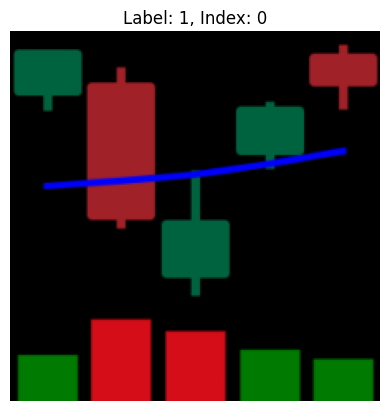

In [17]:
import pandas as pd
from PIL import Image
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

class StockImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label, idx

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = StockImageDataset(train_df, transform=basic_transform)
val_dataset   = StockImageDataset(val_df, transform=basic_transform)
test_dataset  = StockImageDataset(test_df, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Test one batch
images, labels, idx = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

# Show one example image
image, label, idx = train_dataset[0]
img_np = image.permute(1, 2, 0).numpy()

plt.imshow(img_np)
plt.title(f"Label: {label}, Index: {idx}")
plt.axis("off")
plt.show()

Hvis PyTorch bruger CPU i stedet for Nvidia GPU er det fordi du har installeret en CPU version af PyTorch. Så kan man køre følgende kommandoer for at få CUDA version med PyTorch
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [18]:
import torch
import sys

print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Python: c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
Torch CUDA version: 12.6
GPU count: 1
GPU name: NVIDIA GeForce RTX 4070


In [19]:
import os
import torch
import torch.nn as nn


class JiangI5RGB(nn.Module):
    """
    Jiang-inspired CNN adapted to your exact use case:
    - only I5 (5 lookback days)
    - predicts 5 days ahead (R5)
    - input images are 224x224 RGB, like in your supervisor's setup

    Important thesis note:
    This is NOT an exact line-by-line copy of Jiang.
    It is a Jiang-style adaptation for your RGB image pipeline.
    """

    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            # ============================================================
            # BLOCK 1
            # ============================================================

            nn.Conv2d(
                in_channels=3,
                # MODIFIED FROM JIANG:
                # Jiang's original images are black/white and effectively 2D sparse chart images.
                # Your images are RGB, so we must use 3 input channels.
                out_channels=32,
                # MODIFIED FROM JIANG:
                # Jiang starts with 64 filters in the first block for the I5 model.
                # I reduce this to 32 to make training lighter and faster for your thesis.
                kernel_size=(5, 3),
                # DIRECTLY FROM JIANG:
                # Jiang uses 5x3 convolution filters because the chart images are sparse
                # in the vertical dimension.
                stride=(1, 1),
                # MODIFIED FROM JIANG:
                # Jiang uses special first-layer vertical stride/dilation settings
                # for sparse raw images.
                # Because your images are already rendered 224x224 RGB charts,
                # I keep standard stride=(1,1) for a simpler and more stable implementation.
                padding=(2, 1),
                # NOT SPECIFICALLY FROM JIANG:
                # This padding keeps output size roughly stable before pooling.
                bias=False
                # NOT SPECIFICALLY FROM JIANG:
                # When BatchNorm comes right after Conv, bias is usually unnecessary.
            ),

            nn.BatchNorm2d(32),
            # DIRECTLY FROM JIANG:
            # Jiang states that batch normalization is applied between
            # convolution and nonlinear activation.

            nn.LeakyReLU(negative_slope=0.01, inplace=True),
            # DIRECTLY FROM JIANG:
            # Jiang explicitly uses leaky ReLU as the activation.

            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            # DIRECTLY FROM JIANG:
            # Jiang uses 2x1 max-pooling because of the image structure.

            # ============================================================
            # BLOCK 2
            # ============================================================

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                # MODIFIED FROM JIANG:
                # Jiang doubles filters by layer and would go 64 -> 128 for I5.
                # Here I go 32 -> 64 to keep the model lighter.
                kernel_size=(5, 3),
                # DIRECTLY FROM JIANG:
                # Same 5x3 convolution choice as Jiang.
                stride=(1, 1),
                # MODIFIED / PRACTICAL:
                # Again, standard stride rather than Jiang's sparse-first-layer trick.
                padding=(2, 1),
                bias=False
            ),

            nn.BatchNorm2d(64),
            # DIRECTLY FROM JIANG

            nn.LeakyReLU(negative_slope=0.01, inplace=True),
            # DIRECTLY FROM JIANG

            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            # DIRECTLY FROM JIANG
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            # MODIFIED FROM JIANG:
            # Jiang's original model flattens the final feature map directly
            # and then uses a fully connected layer.
            #
            # I replace that with AdaptiveAvgPool2d((1,1)) because your 224x224 RGB
            # images would otherwise create a much larger classifier head.
            # This keeps training cheaper and cleaner while preserving the CNN logic.

            nn.Flatten(),
            # PARTLY JIANG-LIKE:
            # Jiang also flattens before the final classifier,
            # but here flatten happens after adaptive pooling.

            nn.Dropout(0.5),
            # DIRECTLY FROM JIANG:
            # Jiang uses 50% dropout on the fully connected layer.

            nn.Linear(64, num_classes)
            # MODIFIED FROM JIANG:
            # Jiang's final FC input is much larger because he flattens the whole
            # final CNN output. Here the input is only 64 because of adaptive pooling.
            #
            # num_classes=2 matches your binary Up/Down setup.
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                # DIRECTLY FROM JIANG:
                # Jiang uses Xavier initialization.
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
                    # PRACTICAL CHOICE:
                    # Zero bias init is standard and harmless here.

    def forward(self, x):
        x = self.features(x)
        # Pass image through the 2 Jiang-style CNN blocks.

        x = self.classifier(x)
        # Convert learned feature maps into final Up/Down class scores.

        return x
        # Return raw logits.
        # CrossEntropyLoss will apply the proper classification logic internally.


def count_parameters(model):
    # NOT FROM JIANG:
    # This is just a helper so you can see how large the model is.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    # NOT FROM JIANG:
    # Standard PyTorch training function.
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    # NOT FROM JIANG:
    # Standard PyTorch evaluation function.
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = JiangI5RGB(num_classes=2).to(device)
print("Trainable params:", count_parameters(model))

criterion = nn.CrossEntropyLoss()
# DIRECTLY FROM JIANG:
# Jiang treats this as a binary classification problem and uses cross-entropy loss.

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# PARTLY FROM JIANG, PARTLY MODIFIED:
# Adam is directly from Jiang.
# The learning rate is MODIFIED.
# Jiang uses 1e-5, but here I use 1e-4 because this is a lighter adapted model
# and in practice that is often easier to train with your setup.
# If training is unstable, try 1e-5.

num_epochs = 15
# MODIFIED / PRACTICAL:
# Jiang uses early stopping, so the exact epoch count is less important.
# 15 is just a reasonable upper limit.

best_val_loss = float("inf")

patience = 3
# MODIFIED FROM JIANG:
# Jiang stops after 2 consecutive non-improving epochs.
# I use 3 to make training a bit less sensitive to noisy validation loss.

patience_counter = 0

model_save_path = os.path.join(data_folder, "best_cnn_i5_rgb_jiang.pth")
# NOT FROM JIANG:
# Just your local save path and filename.

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print("  Saved best model.")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  Early stopping triggered.")
            break
            # DIRECTLY JIANG-LIKE IDEA, MODIFIED IMPLEMENTATION:
            # Jiang uses early stopping after 2 bad epochs.
            # Here we do the same idea, but with patience=3.

Using device: cuda
Trainable params: 32482
Epoch 1/15
  Train loss: 0.7697 | Train acc: 0.4947
  Val   loss: 0.6829 | Val   acc: 0.5749
  Saved best model.
Epoch 2/15
  Train loss: 0.7513 | Train acc: 0.5021
  Val   loss: 0.6935 | Val   acc: 0.5233
Epoch 3/15
  Train loss: 0.7546 | Train acc: 0.4974
  Val   loss: 0.6835 | Val   acc: 0.5749
Epoch 4/15
  Train loss: 0.7332 | Train acc: 0.5079
  Val   loss: 0.6831 | Val   acc: 0.5749
  Early stopping triggered.


In [20]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = JiangI5RGB(num_classes=2).to(device)
model_save_path = os.path.join(data_folder, "best_cnn_i5_rgb_jiang.pth")

model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc:  {test_acc:.4f}")

Test loss: 0.6979
Test acc:  0.5184


In [21]:
import os
import torch
import torch.nn.functional as F

# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = JiangI5RGB(num_classes=2).to(device)
model_save_path = os.path.join(data_folder, "best_cnn_i5_rgb_jiang.pth")
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

# Reset index so dataset idx matches dataframe row
test_df = test_df.reset_index(drop=True)

# Create empty column for predicted probability of "up"
test_df["pred_prob_up"] = None

with torch.no_grad():
    for images, labels, indices in test_loader:
        images = images.to(device)

        outputs = model(images)

        # Option A: convert 2 logits to probabilities
        probs_up = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()

        for i, idx in enumerate(indices.numpy()):
            test_df.loc[idx, "pred_prob_up"] = float(probs_up[i])

# Optional: also create predicted class from 0.5 threshold
test_df["pred_label"] = (test_df["pred_prob_up"].astype(float) >= 0.5).astype(int)

# Save file
predictions_path = os.path.join(data_folder, "test_predictions.csv")
test_df.to_csv(predictions_path, index=False)

print("Saved predictions to:", predictions_path)
print(test_df.head())

Saved predictions to: vol_1_ma_1_bb_0_rsi_0\test_predictions.csv
                                          image_path ticker start_date  \
0  vol_1_ma_1_bb_0_rsi_0\AMGN\AMGN_2024-03-26_to_...   AMGN 2024-03-26   
1  vol_1_ma_1_bb_0_rsi_0\AGG\AGG_2024-03-26_to_20...    AGG 2024-03-26   
2  vol_1_ma_1_bb_0_rsi_0\AMAT\AMAT_2024-03-26_to_...   AMAT 2024-03-26   
3  vol_1_ma_1_bb_0_rsi_0\AAPL\AAPL_2024-03-26_to_...   AAPL 2024-03-26   
4  vol_1_ma_1_bb_0_rsi_0\ACN\ACN_2024-03-26_to_20...    ACN 2024-03-26   

    end_date  close_now  close_future  label       date  file_exists  \
0 2024-04-02     276.21        270.36      0 2024-04-02         True   
1 2024-04-02      96.87         96.92      1 2024-04-02         True   
2 2024-04-02     206.11        210.41      1 2024-04-02         True   
3 2024-04-02     168.84        169.67      1 2024-04-02         True   
4 2024-04-02     336.46        334.45      0 2024-04-02         True   

  pred_prob_up  pred_label  
0     0.585136           1  

$$r_{t,t+5}=\frac{close\_future - close\_now}{close\_now}$$

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pred_path = os.path.join(data_folder, "test_predictions.csv")
df = pd.read_csv(pred_path)

df["rebalance_date"] = pd.to_datetime(df["end_date"])
df["future_return_5d"] = (df["close_future"] - df["close_now"]) / df["close_now"]

print(df[["ticker", "rebalance_date", "pred_prob_up", "future_return_5d"]].head())

  ticker rebalance_date  pred_prob_up  future_return_5d
0   AMGN     2024-04-02      0.585136         -0.021180
1    AGG     2024-04-02      0.572310          0.000516
2   AMAT     2024-04-02      0.578465          0.020863
3   AAPL     2024-04-02      0.579969          0.004916
4    ACN     2024-04-02      0.562993         -0.005974


In [23]:
n_groups = 10   # use 10 in final analysis

In [24]:
def assign_groups(prob_series):
    if len(prob_series) < n_groups:
        return pd.Series([np.nan] * len(prob_series), index=prob_series.index)

    ranked = prob_series.rank(method="first")

    return pd.qcut(
        ranked,
        q=n_groups,
        labels=False
    ) + 1

df["group"] = (
    df.groupby("rebalance_date")["pred_prob_up"]
      .transform(assign_groups)
)

df = df.dropna(subset=["group"]).copy()
df["group"] = df["group"].astype(int)

print(df[["ticker", "rebalance_date", "pred_prob_up", "group", "future_return_5d"]].head())

  ticker rebalance_date  pred_prob_up  group  future_return_5d
0   AMGN     2024-04-02      0.585136     10         -0.021180
1    AGG     2024-04-02      0.572310      4          0.000516
2   AMAT     2024-04-02      0.578465      8          0.020863
3   AAPL     2024-04-02      0.579969      9          0.004916
4    ACN     2024-04-02      0.562993      1         -0.005974


In [25]:
portfolio_returns = (
    df.groupby(["rebalance_date", "group"])["future_return_5d"]
      .mean()
      .reset_index()
)

print(portfolio_returns.head())

  rebalance_date  group  future_return_5d
0     2024-04-02      1         -0.025147
1     2024-04-02      2          0.003749
2     2024-04-02      3         -0.013341
3     2024-04-02      4          0.000516
4     2024-04-02      5          0.027561


In [26]:
portfolio_wide = portfolio_returns.pivot(
    index="rebalance_date",
    columns="group",
    values="future_return_5d"
)

portfolio_wide.columns = [f"G{int(c)}" for c in portfolio_wide.columns]

low_col = "G1"
high_col = f"G{n_groups}"

portfolio_wide["H-L"] = portfolio_wide[high_col] - portfolio_wide[low_col]

print(portfolio_wide.head())

                      G1        G2        G3        G4        G5        G6  \
rebalance_date                                                               
2024-04-02     -0.025147  0.003749 -0.013341  0.000516  0.027561  0.009489   
2024-04-09     -0.040000 -0.033154 -0.017458 -0.042862 -0.044669 -0.001709   
2024-04-16      0.007389  0.043066 -0.068457 -0.006972 -0.014834 -0.014642   
2024-04-23     -0.045473 -0.004287 -0.015057  0.001462  0.040126 -0.021294   
2024-04-30      0.041889  0.001887  0.032402  0.078629 -0.024940 -0.000553   

                      G7        G8        G9       G10       H-L  
rebalance_date                                                    
2024-04-02     -0.058387  0.020863  0.004916 -0.021180  0.003967  
2024-04-09     -0.012657 -0.023199 -0.028726 -0.004420  0.035580  
2024-04-16     -0.077525 -0.020620  0.029739  0.010769  0.003380  
2024-04-23      0.020551 -0.020053 -0.025287  0.027996  0.073469  
2024-04-30      0.043645  0.013353  0.096225  0.063

In [27]:
periods_per_year = 252 / 5

def annualized_return(r):
    return r.mean() * periods_per_year

def annualized_sharpe(r):
    std = r.std()
    if std == 0 or pd.isna(std):
        return np.nan
    return (r.mean() / std) * np.sqrt(periods_per_year)

def p_value_mean_zero(r):
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    t_stat, p_val = stats.ttest_1samp(r, popmean=0.0, nan_policy="omit")
    return p_val

def stars_from_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

summary_rows = []

for g in range(1, n_groups + 1):
    col = f"G{g}"
    r = portfolio_wide[col].dropna()

    if g == 1:
        label = "Low"
    elif g == n_groups:
        label = "High"
    else:
        label = str(g)

    p = p_value_mean_zero(r)

    summary_rows.append({
        "Group": label,
        "Ret": annualized_return(r),
        "SR": annualized_sharpe(r),
        "p_value": p,
        "stars": stars_from_p(p)
    })

# Add H-L
r_hl = portfolio_wide["H-L"].dropna()
p_hl = p_value_mean_zero(r_hl)

summary_rows.append({
    "Group": "H-L",
    "Ret": annualized_return(r_hl),
    "SR": annualized_sharpe(r_hl),
    "p_value": p_hl,
    "stars": stars_from_p(p_hl)
})

summary_table = pd.DataFrame(summary_rows)

summary_table["Ret"] = summary_table["Ret"].round(2)
summary_table["SR_display"] = summary_table["SR"].map(lambda x: f"{x:.2f}") + summary_table["stars"]

print(summary_table[["Group", "Ret", "SR_display", "p_value"]].to_string(index=False))

Group   Ret SR_display  p_value
  Low -0.16      -0.82 0.485668
    2  0.41       2.06 0.085875
    3 -0.35      -1.25 0.290299
    4  0.18       0.52 0.656772
    5 -0.21      -0.92 0.434864
    6  0.12       0.48 0.682497
    7  0.14       0.46 0.695487
    8 -0.00      -0.01 0.996157
    9  0.40       1.52 0.201633
 High  0.38       1.08 0.359894
  H-L  0.54       1.55 0.192026


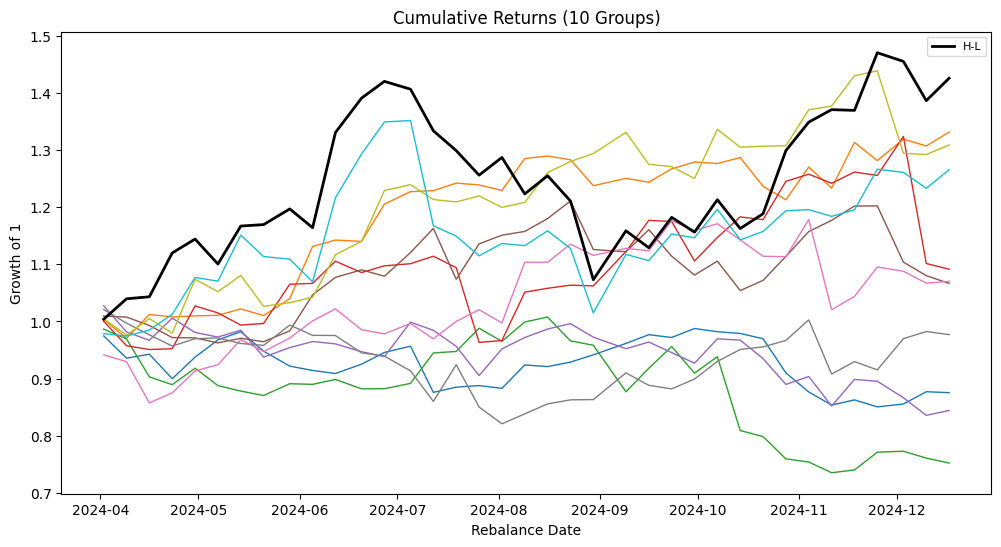

In [28]:
cum_df = (1 + portfolio_wide.fillna(0)).cumprod()

plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(cum_df.index, cum_df[f"G{g}"], linewidth=1)

plt.plot(cum_df.index, cum_df["H-L"], linewidth=2, color="black", label="H-L")

plt.title(f"Cumulative Returns ({n_groups} Groups)")
plt.ylabel("Growth of 1")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()

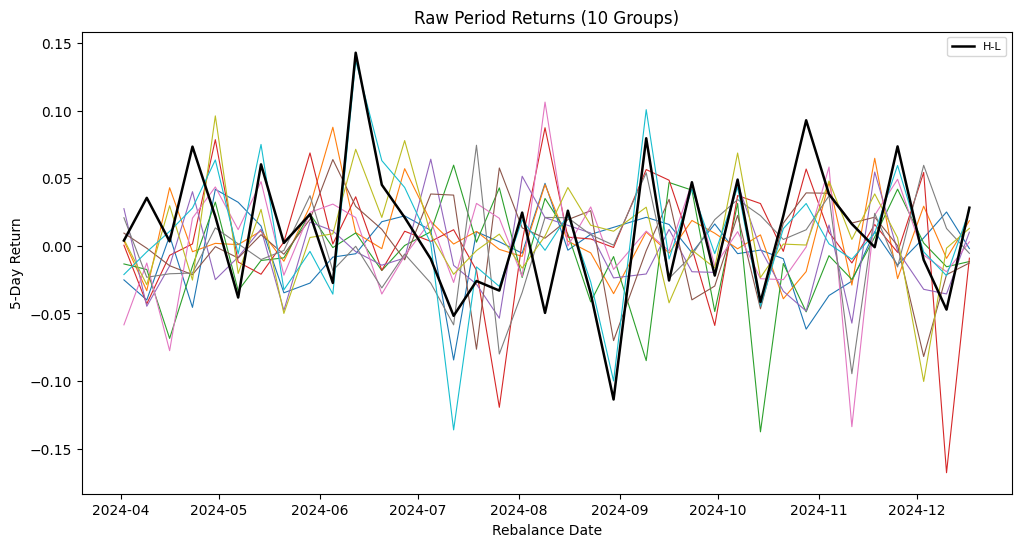

In [29]:
plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(portfolio_wide.index, portfolio_wide[f"G{g}"], linewidth=0.8)

plt.plot(portfolio_wide.index, portfolio_wide["H-L"], linewidth=1.8, color="black", label="H-L")

plt.title(f"Raw Period Returns ({n_groups} Groups)")
plt.ylabel("5-Day Return")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()